# 07 — Relaxed Demeanor Index (exploratory)

> **This is an exploratory composite.** There is no single validated definition of "relaxed demeanor" in the FACS / affect literature. The combination used here is a reasonable first pass that mixes upper-face tension, lower-face tension, and head-motion smoothness — but the specific weighting and component choices should be validated against ratings on your own corpus before drawing strong conclusions.

**Goal:** produce a single 0–1 score per frame where **higher = more relaxed**.

**Components (all are *tension* indicators — we invert them so higher value = less of that tension):**

| Component | Source | What it measures |
|---|---|---|
| `pf_AU04` | Py-Feat | brow lowerer — furrowing, concentration, tension |
| `pf_AU07` | Py-Feat | lid tightener — narrowed, tense eye |
| `pf_AU23` | Py-Feat | lip tightener — thinned, compressed lips |
| `pf_AU24` | Py-Feat | lip pressor — firmly pressed lips |
| `head_jerk` | Py-Feat pose | 2nd derivative magnitude of (pitch, yaw, roll) — how abruptly head direction is changing |

Each component is **min-max normalized** across this video to put everything on a 0–1 scale, then **inverted** (1 − value), then **averaged**.

**Input:** `data/<video>_merged.parquet` from `00_pipeline.ipynb`.  
**Outputs:** per-frame composite time series, per-video mean, per-component bar chart, saved parquet.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

In [2]:
VIDEO_STEM = "sample"

SMOOTH_WINDOW_S = 1.0   # smooth the head-jerk signal over this window (reduces landmark noise)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARQUET_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.parquet"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"
OUT_PATH = DATA_DIR / f"{VIDEO_STEM}_relaxed.parquet"

print("Input :", PARQUET_PATH)
print("Output:", OUT_PATH)

Input : /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_merged.parquet
Output: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_relaxed.parquet


In [3]:
df = pd.read_parquet(PARQUET_PATH)
meta = pd.read_json(META_PATH, typ="series")
FPS = float(meta["effective_fps"])
frame_duration_s = 1.0 / FPS
print(f"{len(df)} sampled frames, effective fps = {FPS:.2f}")

165 sampled frames, effective fps = 6.00


## 1. Extract raw component signals

**What this section does:** pulls the four tension AUs directly, and computes the head-jerk signal from head pose.

**Why these four AUs:**
- `AU04` and `AU07` — upper-face tension, covers concentration / glaring.
- `AU23` and `AU24` — lower-face tension, covers clamped / clenched mouth.

Taken together, they span both halves of the face. If you only use upper-face tension, someone who expresses stress through their mouth reads as relaxed; if only lower-face, someone who furrows their brow reads as relaxed. All four helps.

**Head jerk:** second time-derivative of each pose axis, then combined as 3D magnitude:

$$\text{jerk}_t = \sqrt{(\ddot{\text{pitch}}_t)^2 + (\ddot{\text{yaw}}_t)^2 + (\ddot{\text{roll}}_t)^2}$$

This captures how *suddenly* the head changes direction — relaxed heads move smoothly (low jerk), tense/startled heads snap (high jerk). Note: mathematically this is angular acceleration, not true mechanical jerk (which is 3rd derivative of position); the ticket uses "jerk" as a shorthand for "abrupt motion."

We smooth the jerk signal over a ~1-second window to suppress landmark noise — real muscular snaps happen on longer timescales.

In [4]:
comp = df[["frame", "timestamp"]].copy()
comp["AU04"] = df["pf_AU04"]
comp["AU07"] = df["pf_AU07"]
comp["AU23"] = df["pf_AU23"]
comp["AU24"] = df["pf_AU24"]

# Head jerk: 2nd derivative of each axis, combined as 3D magnitude
pitch_dd = df["pf_Pitch"].diff().diff() / (frame_duration_s ** 2)
yaw_dd = df["pf_Yaw"].diff().diff() / (frame_duration_s ** 2)
roll_dd = df["pf_Roll"].diff().diff() / (frame_duration_s ** 2)
jerk_raw = np.sqrt(pitch_dd**2 + yaw_dd**2 + roll_dd**2)

# Smooth to suppress single-frame noise
W = max(2, int(round(SMOOTH_WINDOW_S * FPS)))
comp["head_jerk"] = jerk_raw.rolling(W, center=True, min_periods=max(2, W//2)).mean()

# Drop leading NaNs from the diffs
comp = comp.dropna(subset=["AU04","AU07","AU23","AU24","head_jerk"]).reset_index(drop=True)
print(f"{len(comp)} usable frames after jerk smoothing")
print(comp[["AU04","AU07","AU23","AU24","head_jerk"]].describe().round(3))

163 usable frames after jerk smoothing
          AU04     AU07     AU23     AU24  head_jerk
count  163.000  163.000  163.000  163.000    163.000
mean     0.177    0.307    0.454    0.351     88.122
std      0.160    0.463    0.201    0.260     44.776
min      0.018    0.000    0.096    0.012     10.506
25%      0.054    0.000    0.265    0.045     61.406
50%      0.111    0.000    0.500    0.358     81.436
75%      0.234    1.000    0.617    0.572    100.665
max      0.691    1.000    0.809    0.855    274.565


## 2. Min-max normalize and invert

**What this section does:** puts every component on a 0–1 scale by min-max scaling within this video, then inverts each so that **higher = more relaxed** on every component.

**Why min-max within this video (not globally):** the four AUs are already 0–1 but their *typical* ranges differ subject-to-subject (some people have a resting-face AU04 around 0.3, others near 0). Min-max across the video standardizes to the observed spread on that video. Head jerk is unbounded, so this normalization is required to combine it with the AUs.

**Caveat this introduces:** a video where the subject is tense the whole time will still produce a full 0–1 range for each component, because min-max makes the within-video minimum = 0. The composite is therefore *relative within a video*, not absolute. Cross-video comparisons require either (a) z-scoring against a shared reference corpus, or (b) fixed global ranges. This notebook prints the min/max used so you can do those conversions manually.

**Invert:** `relaxation_component = 1 − normalized_tension`. So 1.0 on every component means "lowest tension observed on this video"; 0.0 means "highest tension observed."

In [5]:
components = ["AU04", "AU07", "AU23", "AU24", "head_jerk"]
norm_info = {}

for c in components:
    v = comp[c]
    vmin = float(v.min())
    vmax = float(v.max())
    span = vmax - vmin if vmax > vmin else 1.0  # avoid div-by-zero on constant signals
    comp[f"{c}_rel"] = 1.0 - (v - vmin) / span
    norm_info[c] = {"min": round(vmin, 4), "max": round(vmax, 4), "span": round(span, 4)}

pd.DataFrame(norm_info).T

,min,max,span
AU04,0.0180,0.6910,0.6730
AU07,0.0000,1.0000,1.0000
AU23,0.0955,0.8086,0.7131
AU24,0.0118,0.8547,0.8429
head_jerk,10.5064,274.5652,264.0588


## 3. Composite (unweighted average)

**What this section does:** averages the five inverted-and-normalized components into one score per frame.

**Why unweighted:** no literature consensus exists on which of these carries more signal. Equal weighting is the honest default; if you later have rated relaxation labels on a corpus, fit weights by regression.

**Interpretation:**
- Score near 1.0 → subject is in the relaxed end of their *own* within-video range on every component.
- Score near 0.0 → subject is in the tense end on every component.
- Score near 0.5 → mixed — inspect component breakdown below to see which components disagree.

In [6]:
rel_cols = [f"{c}_rel" for c in components]
comp["relaxed"] = comp[rel_cols].mean(axis=1)

print(comp["relaxed"].describe().round(3))
print(f"\nPer-video mean relaxed score: {comp['relaxed'].mean():.3f}")

count    163.000
mean       0.651
std        0.121
min        0.240
25%        0.579
50%        0.683
75%        0.728
max        0.931
Name: relaxed, dtype: float64

Per-video mean relaxed score: 0.651


## 4. Per-component contribution (bar chart)

**What this chart shows:** the mean of each component across the video, so you can see which tension dimensions dominated.

**How to read it:**
- All bars near 0.5 → tension was spread evenly across components. The composite is a fair summary.
- One component very low → that dimension was consistently tense, dragging the average down. Inspect the source video for whether that tension is real (e.g. sustained brow furrow) or artifact (AU detection quirk on this subject).
- One component very high → that dimension was consistently relaxed. Perhaps the subject doesn't normally use that muscle group.

**Remember:** these are within-video-relative scores. A video of a fully-tense subject will still show bars between 0 and 1 because min-max normalizes to the observed range.

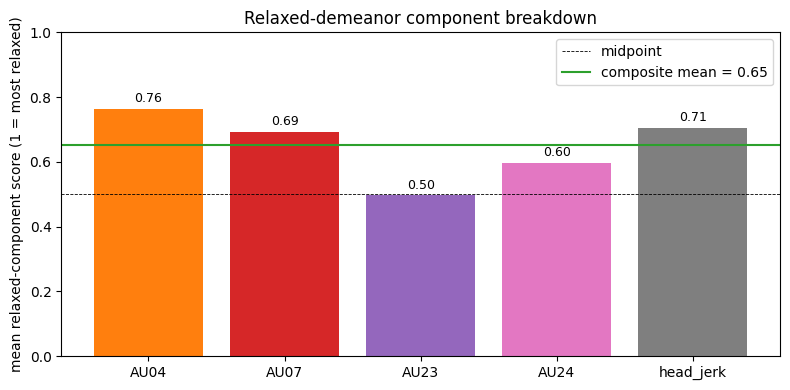

In [7]:
means = comp[rel_cols].mean().rename(lambda s: s.replace("_rel", ""))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(means.index, means.values, color=["tab:orange", "tab:red", "tab:purple", "tab:pink", "tab:gray"])
ax.axhline(0.5, color="k", lw=0.6, ls="--", label="midpoint")
ax.axhline(comp["relaxed"].mean(), color="tab:green", lw=1.5, label=f"composite mean = {comp['relaxed'].mean():.2f}")
ax.set_ylim(0, 1)
ax.set_ylabel("mean relaxed-component score (1 = most relaxed)")
ax.set_title("Relaxed-demeanor component breakdown")
ax.legend()
for b, v in zip(bars, means.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Per-frame composite time series

**What this chart shows:** the composite relaxed score over time (thick line) with individual component contributions (thin lines).

**What to look for:**
- Composite stable near a single level → subject's relaxation was consistent.
- Composite fluctuates widely → affective changes through the video; line up time ranges with the video to see what triggered them.
- Single component diverges from the pack → spotlight on that AU / head-jerk; might indicate a specific behavior (e.g. a sustained lip-press during a particular question).

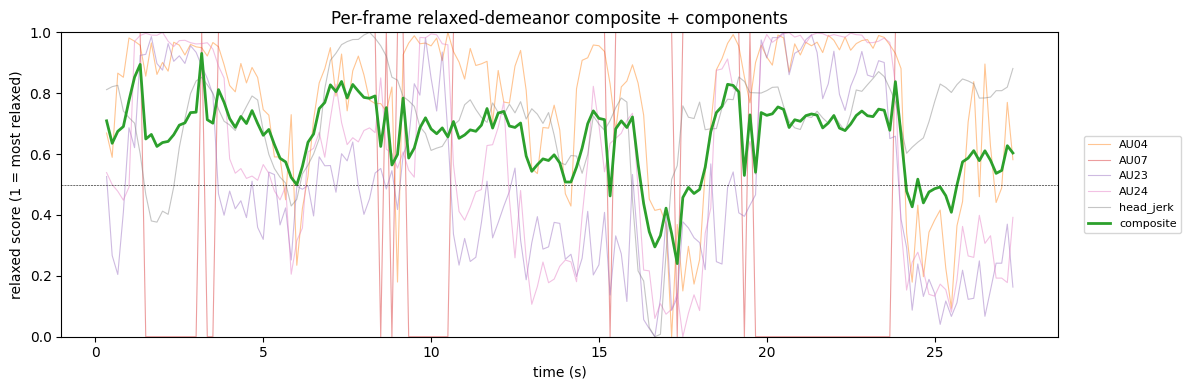

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
t = comp["timestamp"].to_numpy()
for c, color in zip(components, ["tab:orange", "tab:red", "tab:purple", "tab:pink", "tab:gray"]):
    ax.plot(t, comp[f"{c}_rel"], color=color, alpha=0.45, lw=0.8, label=c)
ax.plot(t, comp["relaxed"], color="tab:green", lw=2.0, label="composite")
ax.axhline(0.5, color="k", lw=0.4, ls="--")
ax.set_ylim(0, 1)
ax.set_xlabel("time (s)")
ax.set_ylabel("relaxed score (1 = most relaxed)")
ax.set_title("Per-frame relaxed-demeanor composite + components")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## 6. Save composite for reuse

In [9]:
out = comp[["frame", "timestamp"] + components + rel_cols + ["relaxed"]].copy()
out.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}  ({len(out)} rows)")
print(f"Per-video mean relaxed: {comp['relaxed'].mean():.3f}")

Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_relaxed.parquet  (163 rows)
Per-video mean relaxed: 0.651
